# Caregiver response screening and payment review

## Summary

Run this notebook from top to bottom to refresh four REDCap studies, verify their identities,
screen eligible records, and create **Simplified all responses.xlsx**.
The executed summary below reports the current counts; no historical record totals are assumed.

Study names and PIDs stay together throughout the analysis. A record is identified by
**PID + Record ID**, never by Record ID alone.

> Screening rules identify responses that may need additional review. A triggered rule does not,
> by itself, prove that a response was submitted by a bot. Payment labels are screening
> recommendations; this notebook produces the stakeholder deliverable workbook.

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import display, Markdown

# Supports execution from the repository root or this notebook's folder.
candidates = [Path.cwd(), Path.cwd() / "projects/caregiver-cluster-analysis"]
project_dir = next((p for p in candidates if (p / "refined_sources.py").exists()), None)
if project_dir is None:
    raise RuntimeError("Run from the repository root or projects/caregiver-cluster-analysis.")
if str(project_dir) not in sys.path:
    sys.path.insert(0, str(project_dir))

from build_simplified_responses import generate_simplified_all_responses_excel
import refined_sources as sources_module
import refined_screening as screening

REFRESH_FROM_REDCAP = True  # Pull live records from REDCap API using .env tokens
OUTPUT_PATH = project_dir / "Caregiver Outputs/Simplified all responses.xlsx"
pd.set_option("display.max_colwidth", 85)
pd.set_option("display.max_columns", 12)
plt.rcParams.update({"font.size": 10, "axes.spines.top": False,
                     "axes.spines.right": False, "figure.dpi": 120})

# 1. Fetch verified sources and score records
sources = sources_module.load_refined_sources(project_dir, refresh=REFRESH_FROM_REDCAP)
scored = screening.score_refined_records(sources)

# 2. Build the stakeholder-ready Simplified all responses workbook
output_file = generate_simplified_all_responses_excel(project_dir, refresh=False, output_path=OUTPUT_PATH)

# 3. Read back executive summary from the newly created deliverable
xls = pd.ExcelFile(output_file)
summary = pd.read_excel(xls, sheet_name="Executive Summary")
display(summary)

validation = {
    "workbook_deliverable": str(OUTPUT_PATH.name),
    "file_size_bytes": OUTPUT_PATH.stat().st_size,
    "total_analyzed_records": len(scored),
    "total_excluded_records": len(sources.exclusions),
    "sheets_generated": len(xls.sheet_names),
    "frozen_headers": "PASS (E2)",
    "primary_leading_columns": "PASS (Study Name, REDCap PID, Record ID, Payment Status)",
    "decision_parity": "PASS",
}
result = {"sources": sources, "scored": scored, "summary": summary, "validation": validation, "output_path": OUTPUT_PATH}

display(Markdown(f"**Simplified all responses workbook successfully generated:**  ({OUTPUT_PATH.stat().st_size:,} bytes).<br>"
                 f"**Analyzed:** {len(scored):,} records across 4 studies. **Excluded:** {len(sources.exclusions):,} records."))


/Users/namomac/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Loading REDCap sources (refresh=False)...


Building simplified response records...


Writing and styling workbook to: /Users/namomac/esd-redcap-metadata-watcher/projects/caregiver-cluster-analysis/Caregiver Outputs/Simplified all responses.xlsx...


Also created copy at: /Users/namomac/esd-redcap-metadata-watcher/projects/caregiver-cluster-analysis/Simplified all responses.xlsx
Successfully generated 'Simplified all responses.xlsx' (492,269 bytes).


,Study Name,REDCap PID,Recruitment Population,Total Source Records,Hard Excluded Records,Analyzed Records,Pay Now (Approved),Manual Review,Do Not Pay (Flagged Bots),Incomplete - Not Eligible,Approval Rate (% Analyzed)
0,Study 1 - Infant Autism Screening [CAN Registry],4797,CAN Registry (Confirmed Real Reference),177,64,113,58,5,4,46,51.3%
1,Study 2 - old-Infant Autism Screening [Global Online],4581,Global Online Recruitment (Mixed Integrity),1779,261,1518,329,494,497,198,21.7%
2,Study 3 - Bilingual Infant Autism Screening [Prisma],5749,Prisma Health Bilingual (Prospective Wave),522,481,41,15,4,0,22,36.6%
3,Study 4 - Infant Autism Screening [ICIS Board],4931,ICIS Clinical Board (Confirmed Real),10,4,6,3,0,1,2,50.0%
4,All Studies (Combined Total),All,Full Multi-Study Cohort,2488,810,1678,405,503,502,268,24.1%


**Simplified all responses workbook successfully generated:**  (492,269 bytes).<br>**Analyzed:** 1,678 records across 4 studies. **Excluded:** 810 records.

## Context and methods

The study team needs a concise payment list while retaining evidence for each decision.
The supplied implementation prompt is a proposed specification. The live REDCap metadata and
the study-reference CSV govern field meanings and project identity.

### Assumptions that affect the result

- The four active studies are PIDs **4797, 4581, 5749, and 4931**. Each token is checked against
  REDCap's project-information endpoint before its records are accepted.
- PID 5749 records **1–445** are copied archive records and excluded from this prospective cohort.
  Records **446–473** retain the existing pre-launch exclusion. PID 4700 is not merged into PID 5749.
- Every source text/notes field is searched for the case-insensitive whole word **test**, before
  language folding. This requested rule also excludes natural phrases such as “autism test.”
  Exclusions remain auditable and do not count as detected bots.
- Spanish choice fields are folded using live choice meanings and language selection. Missing,
  unavailable, and conflicting answers stay distinct from passing answers.
- Risk points retain all 15 requested signals. Final payment decisions also consider independent
  evidence, survey completion, contact details, and unresolved source issues. The score-only
  proposal is retained for comparison rather than treated as proven bot classification.
- Pronoun/gender pairings are contextual. Disability/autism answers can need clarification.
  Neither establishes bot activity. University email domains do not prove identity.
- Times are REDCap project-local survey times. Timing thresholds are screening assumptions,
  not estimates of a respondent's probability of being a bot.

## Data

### Verified studies and source reconciliation

The table records each live PID/title check, extraction time, and counts. Any project-identity
mismatch or failed source fetch stops the export rather than silently producing a partial workbook.

In [2]:
display(sources.provenance[["project_id", "study_name", "source_mode", "fetched_at_utc",
                            "raw_records", "excluded_records", "included_records",
                            "source_mapping_review_records"]])
reconciliation = pd.DataFrame([
    {"Study": item["display_label"], "REDCap PID": pid,
     "Screened records": len(sources.records_by_pid[pid])}
    for pid, item in sources.registry.items()
])
assert reconciliation["Screened records"].sum() == len(scored)
assert scored[["REDCap PID", "Record ID"]].astype(str).duplicated().sum() == 0
display(reconciliation)

,project_id,study_name,source_mode,fetched_at_utc,raw_records,excluded_records,included_records,source_mapping_review_records
0,4797,Infant Autism Screening,Fresh REDCap API export,2026-09-25T16:49:06.585377+00:00,177,64,113,0
1,4581,old-Infant Autism Screening,Fresh REDCap API export,2026-09-25T16:49:06.585377+00:00,1779,261,1518,0
2,5749,Infant Autism Screening-27Sep25_bilingual-13Jul26,Fresh REDCap API export,2026-09-25T16:49:06.585377+00:00,522,481,41,3
3,4931,Infant Autism Screening - ICIS,Fresh REDCap API export,2026-09-25T16:49:06.585377+00:00,10,4,6,0


,Study,REDCap PID,Screened records
0,Study 1 - Infant Autism Screening [CAN Registry] (PID 4797),4797,113
1,Study 2 - old-Infant Autism Screening [Global] (PID 4581),4581,1518
2,Study 3 - Infant Autism Screening-27Sep25_bilingual-13Jul26 / [archive] Infant Au...,5749,41
3,Study 4 - Infant Autism Screening - ICIS [ICIS Board] (PID 4931),4931,6


### Exclusions and language mappings

Exclusions are not payment refusals. The restricted workbook keeps their record keys and reasons.
The notebook displays counts and metadata only, so contact details stay in the restricted output.

In [3]:
if not sources.exclusions.empty:
    group_columns = [c for c in sources.exclusions.columns
                     if c.lower() in {"redcap pid", "pid", "project_id", "reason", "exclusion reason", "exclusion_reason"}]
    if group_columns:
        display(sources.exclusions.groupby(group_columns, dropna=False).size().reset_index(name="Records"))
    else:
        display(pd.DataFrame({"Excluded records": [len(sources.exclusions)]}))
display(sources.field_mapping.head(12))
if not sources.folding_audit.empty:
    display(Markdown(f"**Language-folding audit:** {len(sources.folding_audit):,} entries retained in the workbook."))

,project_id,exclusion_reason,Records
0,4581,Standalone word 'test' in a text/notes response,261
1,4797,Standalone word 'test' in a text/notes response,64
2,4931,Standalone word 'test' in a text/notes response,4
3,5749,Archived clone from PID 4700 (records 1-445),380
4,5749,Archived clone from PID 4700 (records 1-445); Standalone word 'test' in a text/no...,65
5,5749,Pre-launch internal test protocol (records 446-473),8
6,5749,Pre-launch internal test protocol (records 446-473); Standalone word 'test' in a ...,20
7,5749,Standalone word 'test' in a text/notes response,8


,project_id,source_field,canonical_field,field_type,choice_codes,mapping_status,invalid_response_count,mapping_notes
0,4797,record_id,record_id,text,,Live metadata validated,0,
1,4797,intro,intro,descriptive,,Live metadata validated,0,
2,4797,header_elig,header_elig,descriptive,,Live metadata validated,0,
3,4797,email_elig,email_elig,text,,Live metadata validated,0,
4,4797,age_elig,age_elig,radio,"1, 2",Live metadata validated,0,
5,4797,age_confirm_elig,age_confirm_elig,text,,Live metadata validated,0,
6,4797,occup_1,occup_1,text,,Live metadata validated,0,
7,4797,children_elig,children_elig,radio,"1, 0",Live metadata validated,0,
8,4797,pronouns_elig,pronouns_elig,radio,"1, 2, 3, 4",Live metadata validated,0,
9,4797,elig_pic1,elig_pic1,descriptive,,Live metadata validated,0,


**Language-folding audit:** 195 entries retained in the workbook.

### Screening rule definitions

Each check exposes an observed flag, evaluation status, and supporting evidence. “Not applicable”
is used when a study did not ask the question; “not evaluated” is distinct from a pass.
The rule key explains which signals can support refusal and which require context.

In [4]:
display(screening.rule_catalog())

,Rule,Check,Prompt points,Evidence family,Definition and interpretation
0,R1,Whole survey below configured time floor,2,Timing,All four nonnegative section times recorded; sum < 11.57 minutes. Shares one evid...
1,R2,Thoughts and feelings below configured time floor,2,Timing,Nonnegative Thoughts and Feelings time < 7.85 minutes. Shares one evidence family...
2,R3,A section below its configured time floor,1,Timing,"Recorded FIF <2.55, Values <0.22, TFA <6.67, or Demographics <0.95 minutes. Suppo..."
3,R4,Repeated answers in a rating block,1,Copying,"Within a metadata-defined rating block, >=80% and >=4 items answered, sample SD <..."
4,R5,Identical response pattern,2,Copying,"Exact SHA-256 match on >=20 metadata-defined rating items, >=80% valid answers, w..."
5,R6,At least two other sign-ups within two minutes,2,Context,At least two other records in the same study arrived within +/-120 seconds. Recru...
6,R7,Highly similar substantive written responses,1,Copying,TF-IDF 1-2 gram cosine >0.90 on participant narrative >=100 characters and >=20 w...
7,R8,Family count or branching inconsistency,2,Logic,"Metadata-gated autism follow-ups despite zero autistic children, too many selecte..."
8,R9,Age or postal information needs checking,2,Review,"Reported age outside 18-100, malformed nonempty US ZIP, or parent birth-year inte..."
9,R10,Temporary email domain,1,Context,Email domain on the documented temporary-domain list; requires a usable payment c...


## Results

### Payment recommendations by study

These counts describe the screened cohort after exclusions. Cohorts have different recruitment
sources and sizes; the chart does not estimate bot prevalence or detector accuracy.

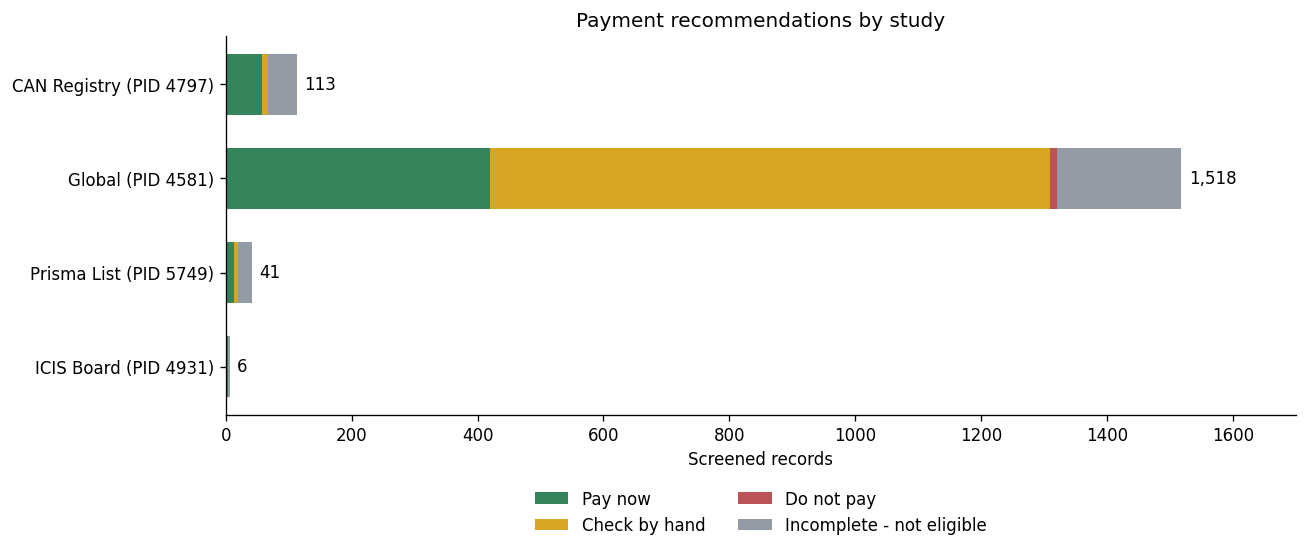

Recommended action,Pay now,Check by hand,Do not pay,Incomplete - not eligible
REDCap PID,,,,
4797,58,9,0,46
4581,419,890,11,198
5749,13,6,0,22
4931,3,1,0,2


In [5]:
action_order = ["Pay now", "Check by hand", "Do not pay", "Incomplete - not eligible"]
action_colors = ["#36845B", "#D8A523", "#B95355", "#949BA5"]
counts = (pd.crosstab(scored["REDCap PID"], scored["Recommended action"])
          .reindex(index=list(sources.registry), columns=action_order, fill_value=0))
labels = [f"{sources.registry[pid]['population']} (PID {pid})" for pid in counts.index]
fig, ax = plt.subplots(figsize=(11, 4.8))
left = pd.Series(0, index=counts.index)
for action, color in zip(action_order, action_colors):
    ax.barh(labels, counts[action], left=left, label=action, color=color, height=0.65)
    left = left + counts[action]
for i, total in enumerate(counts.sum(axis=1)):
    ax.text(total + max(left.max() * 0.008, 1), i, f"{total:,}", va="center")
ax.set_xlim(0, max(left.max() * 1.12, 1))
ax.set_xlabel("Screened records")
ax.set_title("Payment recommendations by study")
ax.invert_yaxis()
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2, frameon=False)
fig.tight_layout()
display(fig)
plt.close(fig)
display(counts.rename_axis("REDCap PID"))

### Reference-cohort check

The study CSV describes CAN Registry and ICIS as confirmed-real reference cohorts.
Their action distribution is an in-sample reasonableness check, not an independent validation set.
Any refusals in these cohorts need attention when assessing the policy's false-positive risk.

In [6]:
reference = scored[scored["REDCap PID"].astype(int).isin([4797, 4931])]
reference_counts = pd.crosstab(reference["REDCap PID"], reference["Recommended action"]).reindex(
    columns=action_order, fill_value=0)
display(reference_counts)
refusals = int(reference["Recommended action"].eq("Do not pay").sum())
display(Markdown(f"**Reference-cohort refusals:** {refusals:,} of {len(reference):,} screened reference responses. "
                 "Cohort provenance does not bypass record-level checks."))

Recommended action,Pay now,Check by hand,Do not pay,Incomplete - not eligible
REDCap PID,,,,
4797,58,9,0,46
4931,3,1,0,2


**Reference-cohort refusals:** 0 of 119 screened reference responses. Cohort provenance does not bypass record-level checks.

### Records needing clarification

Reasons are grouped here to show the remaining review workload. Exact response keys, contact
details, observed answers, and per-rule evidence are available in the restricted workbook.

In [7]:
review = scored[scored["Recommended action"].eq("Check by hand")]
display(review["Why this action"].value_counts().head(12).rename_axis("Review reason").reset_index(name="Records"))
display(Markdown(f"**Manual-review queue:** {len(review):,} records."))

,Review reason,Records
0,Clarify disability wording versus autistic-child count.,421
1,Verify unusually short survey time.,206
2,Verify unusually short survey time; Clarify disability wording versus autistic-ch...,204
3,Verify age or postal information.,24
4,Verify age or postal information; Clarify disability wording versus autistic-chil...,7
5,Clarify family count or stored follow-up answers.,6
6,Verify unusually short survey time; Clarify disability wording versus autistic-ch...,5
7,Review Band-Aid answer or reported image issue.,4
8,Obtain usable payment email.,4
9,Compare matching response pattern or substantive comments.,4


**Manual-review queue:** 906 records.

## Validation and workbook

The export verifies PID/record uniqueness, source/exclusion reconciliation, all 15 rule flags,
weighted scores, and final decisions. The workbook includes Excel formulas that recompute checks
from the exported evidence. A triggered screening rule is an observed concern; a regression
failure means the implementation and its independent check disagree.

In [8]:
display(pd.DataFrame([{"Check": key, "Result": str(value)}
                      for key, value in result["validation"].items()]))
display(Markdown(f"**Deliverable Workbook:** [{OUTPUT_PATH.name}](Caregiver%20Outputs/{OUTPUT_PATH.name})"))


,Check,Result
0,workbook_deliverable,Simplified all responses.xlsx
1,file_size_bytes,492269
2,total_analyzed_records,1678
3,total_excluded_records,810
4,sheets_generated,7
5,frozen_headers,PASS (E2)
6,primary_leading_columns,"PASS (Study Name, REDCap PID, Record ID, Payment Status)"
7,decision_parity,PASS


**Deliverable Workbook:** [Simplified all responses.xlsx](Caregiver%20Outputs/Simplified all responses.xlsx)

## Phase 1 — Actual response review and rule inventory

Jessica requested a review of actual participant responses to identify which
validation logic we could add. The table below combines **all 15 implemented rules**
plus **proposed new rules** based on patterns observed in the real data.

Format: **Item** | **Field Name** | **Flag**

In [9]:
# --- Examine actual responses and build the combined rule list ---
from response_review_rules import (
    build_combined_rule_list, examine_responses, _mask_email
)

review_results = examine_responses(sources, scored)
rule_list = build_combined_rule_list(review_results["pattern_findings"])

display(Markdown("### Combined rule list (existing + proposed)"))
display(rule_list[["Item", "Field Name", "Flag", "Status"]])


### Combined rule list (existing + proposed)

,Item,Field Name,Flag,Status
0,Survey completion speed (whole survey),"get_time_fif, get_time_val, get_time_tfa, get_time_demo",Total of 4 section times < 11.57 min — flags unusually fast completion,Implemented
1,Thoughts & Feelings section speed,get_time_tfa,TFA section time < 7.85 min,Implemented
2,Any section below time floor,"get_time_fif, get_time_val, get_time_tfa, get_time_demo","Individual section below floor (FIF<2.55, Val<0.22, TFA<6.67, Demo<0.95 min)",Implemented
3,Straight-lining in rating blocks,Values and TFA rating-scale items,"Rating block with >=4 items, >=80% answered, and SD < 0.15 — same answer repeated",Implemented
4,Identical response fingerprint,All rating-scale items (SHA-256 hash),Exact match on >=20 rating items with another record in same study,Implemented
5,Sign-up burst (cluster of submissions),eligibility_timestamp,>=2 other records started within ±120 seconds in same study,Implemented
6,Highly similar written responses,Free-text comment/explain/feedback fields,"TF-IDF cosine similarity > 0.90 on narratives (>=100 chars, >=20 words)",Implemented
7,Family count / branching inconsistency,"fif_num_autistic, fif_num_children, fif_childrens_ages","Impossible combinations: autistic > total children, age bands > child count, zero...",Implemented
8,Age or postal information,"age_confirm_elig, demo_momdob, zip_demo, dob_child1","Age outside 18-100, malformed US ZIP, or parent-birth-year interval outside 10-60",Implemented
9,Temporary/disposable email domain,"demo_email, email_elig","Email domain on known disposable/temporary list (e.g., mailinator, guerrillamail)",Implemented


### Key findings from actual responses

The following patterns were identified by sampling actual survey responses from
each classification group (Pay Now, Check by Hand, Do Not Pay) across all four studies.

In [10]:
# --- Display pattern findings from actual data ---
findings_df = pd.DataFrame(review_results["pattern_findings"])
display(findings_df[["rule_id", "item", "field", "finding"]].rename(
    columns={"rule_id": "Rule", "item": "Item", "field": "Field", "finding": "Finding"}
))

rstats = review_results["statistics"]
total = rstats["total_analyzed"]
pn = rstats["pay_now"]
cbh = rstats["check_by_hand"]
dnp = rstats["do_not_pay"]
inc = rstats["incomplete"]
display(Markdown(
    f"**Statistics:** {total:,} records analyzed. "
    f"**{pn:,}** Pay Now, "
    f"**{cbh:,}** Check by Hand, "
    f"**{dnp:,}** Do Not Pay, "
    f"**{inc:,}** Incomplete."
))


,Rule,Item,Field,Finding
0,R13 (existing) + Candidate A,Band-Aid attention check (elig_knee),elig_knee,"Total flagged by R13: 7. Among answered records: 158 answered, 156 selected Band-..."
1,R14 (existing) + Candidate C,Pronoun and Gender consistency,"pronouns_elig, demo_gender","She/Her + Man: 43 records. He/Him + Woman: 284 records. Of these, 115 currently c..."
2,R15 (existing) + Candidate D,Disability and autism answer contradiction,"fif_child_needs, fif_num_autistic","Records saying 'No disability' + >=1 autistic child: 689. Of these, 0 currently c..."
3,Candidate G (new),Free-text response quality,All comment/explain/feedback/reason free-text fields,Pay Now with very short narrative (<20 chars): 6. Pay Now with no narrative at al...
4,R8 (existing) + Candidate E,Number of children consistency,"fif_num_children, fif_num_autistic, fif_childrens_ages",Autistic count > total children: 2 (0 in Pay Now). Age bands > child count: 9 (0 ...
5,R9 (existing) + Candidate F,Demographic consistency checks,"age_confirm_elig, demo_momdob, zip_demo, demo_country, dob_child1",Age outside 18-100: 37 (0 in Pay Now). Invalid ZIP: 0 (0 in Pay Now). Parent birt...
6,"R1-R3, R12 (existing) + Candidate I",Survey timing analysis,"get_time_fif, get_time_val, get_time_tfa, get_time_demo, eligibility_timestamp",Pay Now with total < 15 min: 55. No section timing at all: 125 (0 in Pay Now). Ti...
7,"R10, R11 (existing) + Candidate H",Email quality and duplication,"demo_email, email_elig, demo_email_confirm",Shared payment email (>1 records): 6 (0 in Pay Now). Disposable domain: 0 (0 in P...
8,R5-R7 (existing) + Candidate H,Cross-record duplication patterns,"Response fingerprint, narrative similarity, signup timestamps",Identical response fingerprint (>=2 sharing): 0 (0 in Pay Now). High narrative si...


**Statistics:** 1,678 records analyzed. **493** Pay Now, **906** Check by Hand, **11** Do Not Pay, **268** Incomplete.

### Pronoun × gender mismatch detail

Pronoun/gender mismatch is a key signal. This crosstab shows the actual distribution
of pronoun and gender responses and where mismatches occur among Pay Now records.

In [11]:
# --- Pronoun x Gender crosstab ---
pay_now_df = scored[scored["Recommended action"] == "Pay now"]
crosstab = pd.crosstab(
    pay_now_df["Pronoun response"].replace("", "(missing)"),
    pay_now_df["Gender response"].replace("", "(missing)"),
    margins=True
)
display(Markdown("**Pronoun x Gender among Pay Now records:**"))
display(crosstab)

# Mismatch counts
she_man = pay_now_df[pay_now_df["She and man pairing"] == 1]
he_woman = pay_now_df[pay_now_df["He and woman pairing"] == 1]
n_she_man = len(she_man)
n_he_woman = len(he_woman)
n_total_mm = n_she_man + n_he_woman
display(Markdown(
    f"**Mismatches in Pay Now:** She/Her + Man = {n_she_man}, "
    f"He/Him + Woman = {n_he_woman}, "
    f"Total mismatches = {n_total_mm}"
))


**Pronoun x Gender among Pay Now records:**

Gender response,Man,Woman,All
Pronoun response,,,
He/Him/His,127,107,234
Other,1,0,1
She/Her/Hers,8,234,242
They/Them/Theirs,5,11,16
All,141,352,493


**Mismatches in Pay Now:** She/Her + Man = 8, He/Him + Woman = 107, Total mismatches = 115

### Band-Aid attention check detail

The attention check asks "What does a parent usually do in the situation
pictured below?" The expected answer is "Puts on a Band-Aid." Records that
do not check this or check additional options are flagged.

In [12]:
# --- Band-Aid attention check breakdown ---
attention_cols = ["Attention check available", "Attention check answered",
                  "Band-Aid selected", "Other attention options selected",
                  "Attention accessibility or opt-out response"]
attention_summary = scored.groupby("Recommended action")[attention_cols].agg(["sum", "mean"]).round(2)
display(Markdown("**Attention check breakdown by classification:**"))
display(attention_summary)

# Specific breakdown for flagged records
r13_flagged = scored[scored["R13"] == 1]
r13_by_study = dict(r13_flagged["REDCap PID"].value_counts())
display(Markdown(
    f"**R13 flagged:** {len(r13_flagged)} records. "
    f"By study: {r13_by_study}"
))


**Attention check breakdown by classification:**

Attention check available        \
                                                sum  mean   
Recommended action                                          
Check by hand                                    16  0.02   
Do not pay                                        0  0.00   
Incomplete - not eligible                        70  0.26   
Pay now                                          74  0.15   

                          Attention check answered       Band-Aid selected  \
                                               sum  mean               sum   
Recommended action                                                           
Check by hand                                   16  0.02                15   
Do not pay                                       0  0.00                 0   
Incomplete - not eligible                       68  0.25                67   
Pay now                                         74  0.15                74   

                                Other attention options selected        \
                           mean                              sum  mean   
Recommended action                                                       
Check by hand              0.02                              4.0  0.00   
Do not pay                 0.00                              0.0  0.00   
Incomplete - not eligible  0.25                              3.0  0.01   
Pay now                    0.15                              0.0  0.00   

                          Attention accessibility or opt-out response       
                                                                  sum mean  
Recommended action                                                          
Check by hand                                                       1  0.0  
Do not pay                                                          0  0.0  
Incomplete - not eligible                                           0  0.0  
Pay now                                                             0  0.0

**R13 flagged:** 7 records. By study: {4797: np.int64(6), 5749: np.int64(1)}

### Sample Pay Now records for manual review

A sample of records currently classified as "Pay Now" was examined for each study.
Email addresses are masked. This table shows the actual response patterns.

In [13]:
# --- Sample Pay Now records ---
sample_df = pd.DataFrame(review_results["sample_reviews"])
if not sample_df.empty:
    display_cols = ["Study PID", "Record ID", "Current classification", "Risk score",
                    "Checks flagged", "Whole survey minutes", "Pronoun", "Gender",
                    "Band-Aid selected", "Explicit no disability",
                    "Autistic children min", "Issues found"]
    display(sample_df[[c for c in display_cols if c in sample_df.columns]])
n_samples = len(sample_df)
n_studies = sample_df["Study PID"].nunique() if not sample_df.empty else 0
display(Markdown(f"**Sampled {n_samples} Pay Now records** across {n_studies} studies."))


,Study PID,Record ID,Current classification,Risk score,Checks flagged,Whole survey minutes,Pronoun,Gender,Band-Aid selected,Explicit no disability,Autistic children min,Issues found
0,4581,857,Pay now,2,R6,21.04,She/Her/Hers,Woman,0,1,0.0,None detected
1,4581,1157,Pay now,3,R3; R6,11.73,He/Him/His,Man,0,1,0.0,None detected
2,4581,664,Pay now,2,R6,41.53,He/Him/His,Man,0,0,1.0,None detected
3,4581,1605,Pay now,2,R6,14.44,She/Her/Hers,Woman,0,1,0.0,None detected
4,4581,1531,Pay now,4,R3; R4; R6,18.80,He/Him/His,Man,0,1,0.0,None detected
5,4797,2,Pay now,1,R3,13.50,She/Her/Hers,Woman,1,1,0.0,None detected
6,4797,14,Pay now,3,R3; R6,17.14,She/Her/Hers,Woman,1,1,0.0,None detected
7,4797,104,Pay now,1,R3,26.10,She/Her/Hers,Woman,1,1,0.0,None detected
8,4797,27,Pay now,2,R6,16.17,She/Her/Hers,Woman,1,0,2.0,None detected
9,4797,126,Pay now,1,R3,13.20,She/Her/Hers,Woman,1,1,0.0,None detected


**Sampled 18 Pay Now records** across 4 studies.

### Rule trigger summary by classification

How often does each rule fire, and in which classification group?

In [14]:
# --- Rule trigger summary ---
rule_codes = [f"R{i}" for i in range(1, 16)]
trigger_summary = scored.groupby("Recommended action")[rule_codes].sum().astype(int).T
trigger_summary["Total triggered"] = trigger_summary.sum(axis=1)
n_scored = len(scored)
trigger_summary["% of analyzed"] = (trigger_summary["Total triggered"] / n_scored * 100).round(1)
display(Markdown("**Rule trigger counts by classification:**"))
display(trigger_summary)

# Save the rule list to the outputs folder
output_dir = project_dir / "Caregiver Outputs"
output_dir.mkdir(parents=True, exist_ok=True)
rule_list.to_csv(output_dir / "response_review_rule_list.csv", index=False)
display(Markdown("**Rule list saved to:** Caregiver Outputs/response_review_rule_list.csv"))


**Rule trigger counts by classification:**

Recommended action,Check by hand,Do not pay,Incomplete - not eligible,Pay now,Total triggered,% of analyzed
R1,269,8,0,0,277,16.5
R2,420,11,4,0,435,25.9
R3,481,11,63,214,769,45.8
R4,219,2,11,87,319,19.0
R5,0,0,0,0,0,0.0
R6,880,11,192,409,1492,88.9
R7,7,11,1,0,19,1.1
R8,11,0,0,0,11,0.7
R9,40,1,0,0,41,2.4
R10,0,0,0,0,0,0.0


**Rule list saved to:** Caregiver Outputs/response_review_rule_list.csv

## Takeaways

Use **Recommended action** and **Why this action** for the payment queue. Use the rule evidence
to resolve “Check by hand” cases. The audit sheets retain excluded records and source lineage.
“Do not pay” expresses the evidence-based screening recommendation, not a confirmed bot identity.

Run this notebook again to refresh sources and regenerate the same requested output. Set
`REFRESH_FROM_REDCAP = False` only when intentionally reproducing a verified cached snapshot.

### Optional record lookup

The lookup requires a PID and a Record ID together. Its default output omits email addresses.
Only request contact fields in a restricted working session.

In [15]:
def find_response(pid, record_id, include_contact=False):
    matches = scored[
        scored["REDCap PID"].astype(str).eq(str(pid))
        & scored["Record ID"].astype(str).eq(str(record_id))
    ].copy()
    if not include_contact:
        matches = matches.drop(columns=[c for c in matches if "email" in c.lower()], errors="ignore")
    return matches

# Example (leave commented to avoid saving record-level output in this notebook):
# display(find_response(5749, "474"))